# LightGBM

https://lightgbm.readthedocs.io/en/latest/index.html

LightGBM은 Gradient Boosting 계열을 더 빠르고 가볍게 학습하기 위해 설계된 실무형 라이브러리이다.

기본 철학은 여전히 같다.
즉, 이전 단계 모델의 오차를 다음 트리가 순차적으로 보완해 가는 boosting 구조를 그대로 따른다.

하지만 LightGBM은 같은 boosting 계열 안에서도
"어떻게 하면 더 빠르게 학습하고, 더 적은 메모리로, 더 큰 데이터를 다룰 수 있을까?"에 특히 초점을 둔 라이브러리이다.

그래서 XGBoost가 "기능과 안정성이 강한 실무형 boosting"이라면,
LightGBM은 "속도와 대용량 처리에 더 강한 boosting"이다.

핵심 특징
- Gradient Boosting 기반: 이전 트리의 오차를 다음 트리가 순차적으로 보완한다.
- Histogram 기반 처리: 연속형 값을 여러 구간(bin)으로 묶어 더 빠르게 분할을 계산한다.
- Leaf-wise 트리 성장: 손실 감소가 가장 큰 리프를 우선적으로 분할하여 성능을 높이려는 방식이다.
- 빠른 학습 속도: 큰 데이터셋에서도 비교적 빠르게 학습할 수 있다.
- 메모리 효율: 대용량 데이터 처리에 유리하도록 설계되었다.

다만 Leaf-wise 방식은 성능에 유리할 수 있는 대신,
트리가 너무 복잡해지면 과적합 위험도 커질 수 있으므로 하이퍼파라미터 제어가 중요하다.

## 환경설정

In [17]:
%conda install lightgbm

Channels:
 - conda-forge
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [18]:
import lightgbm

lightgbm.__version__

'4.6.0'

## 이진분류

In [19]:
# 유방암 데이터셋
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True, as_frame=True)
print(X.shape)

X.head()

(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [20]:
# 데이터 준비
from sklearn.model_selection import train_test_split

# 학습/평가셋 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 학습/검증셋 분할
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

print(X_tr.shape, y_tr.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(409, 30) (409,)
(46, 30) (46,)
(114, 30) (114,)


In [21]:
from lightgbm import LGBMClassifier, early_stopping

lgbm_clf = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.01,
    random_state=42
)

lgbm_clf.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr),(X_val, y_val)],
    eval_names=['train', 'val'],
    eval_metric='logloss',     # 이진분류
    callbacks=[
        early_stopping(stopping_rounds=10, verbose=True)
    ]
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 256, number of negative: 153
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000424 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4092
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 30
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.625917 -> initscore=0.514740
[LightGBM] [Info] Start training from score 0.514740
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.01
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [22]:
# 평가
print('train accuracy:', lgbm_clf.score(X_tr, y_tr))
print('test accuracy:', lgbm_clf.score(X_test, y_test))

train accuracy: 0.9975550122249389
test accuracy: 0.9473684210526315


best_iteration_: 306


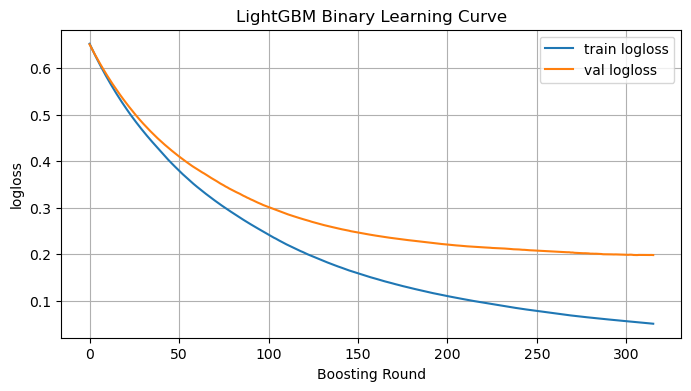

,feature,importance
27,worst concave points,610
21,worst texture,536
22,worst perimeter,376
28,worst symmetry,315
13,area error,303
11,texture error,264
1,mean texture,239
19,fractal dimension error,221
23,worst area,215
10,radius error,190


In [23]:
from matplotlib import pyplot as plt
import pandas as pd
print('best_iteration_:', lgbm_clf.best_iteration_)

# evals_result_:
# - 학습 중 기록된 metric 변화를 저장한다.
results = lgbm_clf.evals_result_

train_logloss = results['train']['binary_logloss']
val_logloss = results['val']['binary_logloss']

plt.figure(figsize=(8, 4))
plt.plot(train_logloss, label='train logloss')
plt.plot(val_logloss, label='val logloss')
plt.xlabel('Boosting Round')
plt.ylabel('logloss')
plt.title('LightGBM Binary Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': lgbm_clf.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.head(10)

## 다중분류

In [24]:
# otto 제품분류 데이터셋
import pandas as pd

otto_df = pd.read_csv('data/otto_train.csv') # otto_train.csv
otto_df.head()

,id,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_85,feat_86,feat_87,feat_88,feat_89,feat_90,feat_91,feat_92,feat_93,target
0,1,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,Class_1
1,2,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,Class_1
2,3,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,Class_1
3,4,1,0,0,1,6,1,5,0,0,...,0,1,2,0,0,0,0,0,0,Class_1
4,5,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,Class_1


In [25]:
# 데이터준비
X = otto_df.drop(['id', 'target'], axis=1)
y = otto_df['target'].factorize()[0] # (숫자인코딩, 문자열클래스)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

print(X_tr.shape, y_tr.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(44551, 93) (44551,)
(4951, 93) (4951,)
(12376, 93) (12376,)


In [26]:
# 위에서 사용한 모델을 이용해서, otto 상품 데이터 셋을 학습하고 평가하기
from lightgbm import LGBMClassifier, early_stopping

lgbm_clf = LGBMClassifier(
    n_estimators=500,
    objective='multiclass',
    num_class=9,
    learning_rate=0.01,
    random_state=42
)

lgbm_clf.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr),(X_val, y_val)],
    eval_names=['train', 'val'],
    eval_metric='multi_logloss',
    callbacks=[
        early_stopping(stopping_rounds=10, verbose=True)
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3052
[LightGBM] [Info] Number of data points in the train set: 44551, number of used features: 93
[LightGBM] [Info] Start training from score -3.468051
[LightGBM] [Info] Start training from score -1.344940
[LightGBM] [Info] Start training from score -2.045350
[LightGBM] [Info] Start training from score -3.134978
[LightGBM] [Info] Start training from score -3.117586
[LightGBM] [Info] Start training from score -1.476504
[LightGBM] [Info] Start training from score -3.081726
[LightGBM] [Info] Start training from score -1.989330
[LightGBM] [Info] Start training from score -2.524910
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[500]	train's multi_logloss: 0.417955	val's multi_lo

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.01
,n_estimators,500
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [27]:
# 평가
print('train accuracy:', lgbm_clf.score(X_tr, y_tr))
print('test accuracy:', lgbm_clf.score(X_test, y_test))

train accuracy: 0.8473659401584701
test accuracy: 0.8078539107950873


best_iteration_: 500
classes_: [0 1 2 3 4 5 6 7 8]
n_classes_: 9
dict_keys(['train', 'val'])
odict_keys(['multi_logloss'])


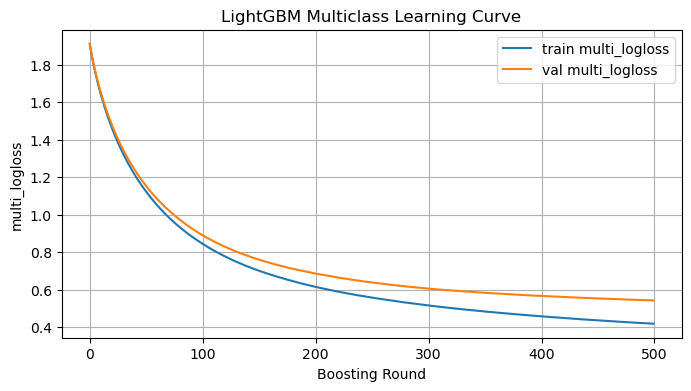

    feature  importance
14  feat_15        4639
39  feat_40        4257
66  feat_67        4185
13  feat_14        4119
42  feat_43        3988
33  feat_34        3631
85  feat_86        3628
59  feat_60        3539
8    feat_9        3376
24  feat_25        3308


In [29]:
print('best_iteration_:', lgbm_clf.best_iteration_)
print('classes_:', lgbm_clf.classes_)
print('n_classes_:', lgbm_clf.n_classes_)

results = lgbm_clf.evals_result_

print(results.keys())                # train, val
print(results['train'].keys())       # multi_logloss 등

train_logloss = results['train']['multi_logloss']
val_logloss = results['val']['multi_logloss']

plt.figure(figsize=(8, 4))
plt.plot(train_logloss, label='train multi_logloss')
plt.plot(val_logloss, label='val multi_logloss')
plt.xlabel('Boosting Round')
plt.ylabel('multi_logloss')
plt.title('LightGBM Multiclass Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

# 특성 중요도 확인
importance_df = pd.DataFrame({
    'feature': X_tr.columns,
    'importance': lgbm_clf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.head(10))

## 회귀

In [30]:
# 캘리포니아 집값 예측
from sklearn.model_selection import train_test_split
df = pd.read_csv('data/california_housing.csv')

# 데이터 구조 확인
print(df.head())
print(df.info())

# 타겟과 피처 분리
X = df.drop('MedHouseVal', axis=1).to_numpy()
y = df['MedHouseVal'].to_numpy()

# 훈련/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 no

In [39]:
from lightgbm import LGBMRegressor, log_evaluation

lgbm_reg = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

lgbm_reg.fit(
    X_tr, y_tr,
    eval_names=['train', 'val'],
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    eval_metric='rmse',
    callbacks=[
        early_stopping(stopping_rounds=20, verbose=True),
        log_evaluation(period=50)
    ]
)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009101 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3052
[LightGBM] [Info] Number of data points in the train set: 44551, number of used features: 93
[LightGBM] [Info] Start training from score 3.842271
Training until validation scores don't improve for 20 rounds
[50]	train's rmse: 1.41502	train's l2: 2.00228	val's rmse: 1.444	val's l2: 2.08515
[100]	train's rmse: 1.29212	train's l2: 1.66959	val's rmse: 1.3464	val's l2: 1.81281
[150]	train's rmse: 1.24557	train's l2: 1.55144	val's rmse: 1.32009	val's l2: 1.74265
[200]	train's rmse: 1.21241	train's l2: 1.46994	val's rmse: 1.30393	val's l2: 1.70024
[250]	train's rmse: 1.18628	train's l2: 1.40725	val's rmse: 1.29274	val's l2: 1.67117
[300]	train's rmse: 1.16281	train's l2: 1.35212	val's rmse: 1.28433	val's l2: 1.6495
[350]	train's rmse: 1.

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [43]:
from sklearn.metrics import root_mean_squared_error

# 평가
print('train r^2:', lgbm_reg.score(X_tr, y_tr))
print('test r^2:', lgbm_reg.score(X_test, y_test))
print('test RMSE:', root_mean_squared_error(y_test, lgbm_reg(X_test)))

train r^2: 0.8113272691953428


c:\Users\test\miniforge3\envs\ai_basic_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


ValueError: X has 8 features, but LGBMRegressor is expecting 93 features as input.

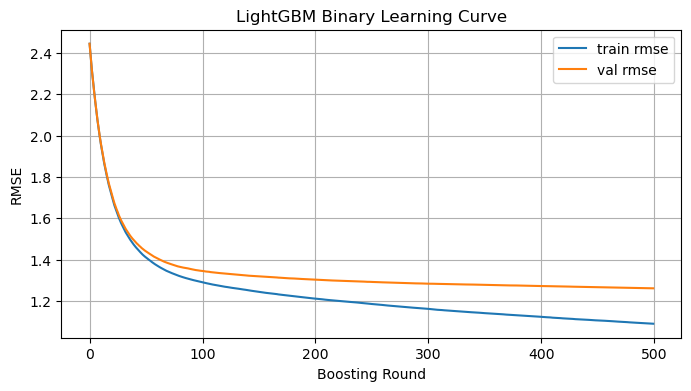

In [42]:
results = lgbm_reg.evals_result_

train_rmse = results['train']['rmse']
val_rmse = results['val']['rmse']

plt.figure(figsize=(8, 4))
plt.plot(train_rmse, label='train rmse')
plt.plot(val_rmse, label='val rmse')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.title('LightGBM Binary Learning Curve')
plt.legend()
plt.grid(True)
plt.show()